## **1. Préliminaires**

### **1.1. Contexte**
Nous pratiquons dans ce notebook l'analyse de données sur les données provenant d'un dataset `heart attack prediction` de [Kaggle](https://kaggle.com/datasets).
Nous allons dans ce notebook explorer , visualiser et interpreter nos variables.

### **1.2. Imports des librairies**

Dans cette section nous allons importer les librairies principales .

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **1.3. Chargement des données**
Nous allons maintenant charger notre dataset .

In [2]:
# chargement du dataset
data = pd.read_csv('../data/data-cleaned.csv')

# affichage d'un extrait
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,0
2,29,1,2,140.0,243.0,0.0,0.0,170.0,0.0,0.0,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,0


### **1.4. Structure et typologie des données**
Nous allons analyser la structure de notre jeu de données et le types des données et changer les types de données si nécessaires.

In [3]:
# dimension du dataset
data.shape

(284, 11)

In [4]:
# affichage des infos sur les variables et leurs types
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284 entries, 0 to 283
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       284 non-null    int64  
 1   sex       284 non-null    int64  
 2   cp        284 non-null    int64  
 3   trestbps  284 non-null    float64
 4   chol      284 non-null    float64
 5   fbs       284 non-null    float64
 6   restecg   284 non-null    float64
 7   thalach   284 non-null    float64
 8   exang     284 non-null    float64
 9   oldpeak   284 non-null    float64
 10  num       284 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 24.5 KB


## **2. Analyse Exploratoire des données**

### **2.1. Analyse univariée**

Nous allons observer la distribution de chaque variable.
Nous allons pour certains graphiques utiliser des diagramme à baton et pour d'autres des diagrammes circulaires.

##### **2.1.1. Fonctions pour les graphiques**
Nous allons créer quelques fonctions

In [290]:
import math

# fonction retournant des pie charts

def show_pie_charts(params: dict):
    nrows = math.ceil(len(params) / 2)
    fig, axes = plt.subplots(nrows=nrows, ncols=2,figsize=(25,35))
    axes_plats = axes.flatten()
    for i, (col, param) in enumerate(params.items()):
        value = param["value"]
        axes_plats[i].pie(
            x=value["count"],
            labels=value[col],
            startangle=value.get('startangle',90),
            colors=value["color"],
            autopct="%.2f%%",
        )
        axes_plats[i].legend()
        axes_plats[i].set_title(f"Repartition des partiens par {col}")
        # axes_plats[i].margins(y=0.2)

    # pour supprimer les graphiques vides
    if len(params)<len(axes_plats):
        for j in range(len(params),len(axes_plats)):
            axes_plats[j].set_axis_off()

In [291]:
# fonction retournant des bar charts

def show_bar_charts(params: dict):
    nrows = math.ceil(len(params) / 2)
    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(30, 20))
    axes_plats = axes.flatten()
    for i, (col, param) in enumerate(params.items()):
        ax=axes_plats[i]
        sns.barplot(ax=ax,data=param['value'],hue=col,y='count',errorbar=None,palette=param.get('palette'))
        ax.set_ylabel("nombre de patients")
        ax.set_xlabel(col)
        ax.set_title(f"Diagramme à barre de repartition par {col}")
        if param.get('yticks') is not None:
            ax.set_yticks(ticks=param.get('yticks'))
    # pour supprimer les graphiques vides
    if len(params)<len(axes_plats):
        for j in range(len(params),len(axes_plats)):
            axes_plats[j].set_axis_off()

##### **2.1.2. La variable `num`** 

In [292]:
# le compte des modalités de nums
num_counts = data["num"].value_counts().reset_index()

# les labels
num_labels = {0: "malade", 1: "sain"}
num_counts.replace({"num": num_labels}, inplace=True)

# les couleurs
num_counts["color"] = sns.color_palette(palette="viridis", n_colors=num_counts.shape[0])

num = {"value":num_counts}

##### **2.1.3. La variable `fbs`** 

In [293]:
# compte des modalités de fbs
fbs_count = data.value_counts(subset=['fbs']).reset_index()

# les labels
fbs_labels = {0: "Normal", 1: "Hyperglycémie"}
fbs_count.replace({"fbs": fbs_labels}, inplace=True)

# les couleurs
fbs_count["color"] = sns.color_palette(palette="pastel", n_colors=fbs_count.shape[0])
fbs = {"value": fbs_count}

##### **2.1.4. La variable `restecg`** 

In [294]:
# le compte des modalités de restecg
restecg_counts = data.value_counts(subset=['restecg']).reset_index()

# les labels
restecg_labels={0:'Normal',1:'Anomalie des ondes ST-T',2:'Hypertrophie ventriculaire gauche probable ou certaine'}
restecg_counts.replace({"restecg": restecg_labels}, inplace=True)

# les couleurs
restecg_counts["color"] = sns.color_palette(
    palette="husl", n_colors=restecg_counts.shape[0]
)

restecg = {"value": restecg_counts,'startangle':180}

##### **2.1.5. La variable `exang`**

In [295]:
# le compte des modalités de exang
exang_counts = data.value_counts(subset=["exang"]).reset_index()

# les labels
exang_labels = {
    0: "Normal",
    1: "Angine induite par l’exercice",
}
exang_counts.replace({"exang": exang_labels}, inplace=True)

# les couleurs
exang_counts["color"] = sns.color_palette(
    palette="magma", n_colors=exang_counts.shape[0]
)
exang = {'value':exang_counts,"startangle":360}

##### **2.1.6. La variable `age`**

In [296]:
# discretisation de la variable âge
age_bins = pd.cut(data["age"], bins=np.arange(20, 80, 10)).value_counts().reset_index()

age = {"value": age_bins, "palette": None, "yticks": np.arange(0, 140, 10)}

##### **2.1.7. La variable `cp`**

In [297]:
# le compte par modalité
cp_counts = data["cp"].value_counts().reset_index()
# labelisation
cp_labels = {
    1: "Angine typique",
    2: "Angine atypique",
    3: "Douleur non angineuse",
    4: "Asymptomatique",
}
cp_counts.replace({"cp": cp_labels}, inplace=True)
cp_yticks=np.arange(0, 140, 10)
cp = {"value": cp_counts, "yticks": cp_yticks, "palette": "plasma"}

##### **2.1.8. La variable `thalach`**

In [298]:
# discretisation de la variable
thalach_bins = (
    pd.cut(data["thalach"], bins=np.arange(80, 220, 20)).value_counts().reset_index()
)

thalach = {"value": thalach_bins,'yticks':None,'palette':'flare'}

##### **2.1.9. La variable `trestbps`**

In [299]:
# discretisation
data['trestbps'].describe()
trestbps_bins = pd.cut(data['trestbps'],bins=np.arange(90,240,30)).value_counts().reset_index()
trestbps_yticks = np.arange(0, 170, 10)
trestbps = {"value": trestbps_bins, "yticks": trestbps_yticks, "palette": "viridis"}

##### **2.1.10. La variable `sex`**

In [300]:
# compte des modalités
sex_counts = data['sex'].value_counts().reset_index()

# labels
sex_labels = {0:'Femme',1:'Homme'}
sex_counts.replace({"sex": sex_labels}, inplace=True)
sex_counts["color"] = sns.color_palette(palette="Set2", n_colors=sex_counts.shape[0])

sex = {'value':sex_counts}

##### **2.1.11. La variable `oldpeak`**

In [306]:
# compte des modalités de oldpeak
oldpeak_counts= pd.cut(data["oldpeak"],bins=np.arange(0,6,1)).value_counts().reset_index()

oldpeak = {"value": oldpeak_counts, "palette": "Spectral"}

##### **2.1.12. La variable `chol`**

In [307]:
data.chol.describe()

count    284.000000
mean     248.352113
std       62.963077
min       85.000000
25%      211.000000
50%      243.000000
75%      275.250000
max      603.000000
Name: chol, dtype: float64

In [ ]:
chol_counts = pd.cut(data["chol"], bins=np.arange(0, 800, 100)).value_counts().reset_index()

chol_yticks = np.arange(0,220,20)

chol = {"value": chol_counts, "palette": "icefire", "yticks": chol_yticks}
chol_counts

,chol,count
0,"(200, 300]",192
1,"(100, 200]",52
2,"(300, 400]",32
3,"(400, 500]",3
4,"(0, 100]",2
5,"(500, 600]",2
6,"(600, 700]",1


##### **2.1.9. Graphiques**

In [309]:
pie_charts_params = {
    "restecg": restecg,
    "fbs": fbs,
    "num": num,
    "exang": exang,
    "sex": sex,
}
bar_charts_params = {
    "cp": cp,
    "thalach": thalach,
    "age": age,
    "trestbps": trestbps,
    "oldpeak": oldpeak,
    "chol": chol,
}

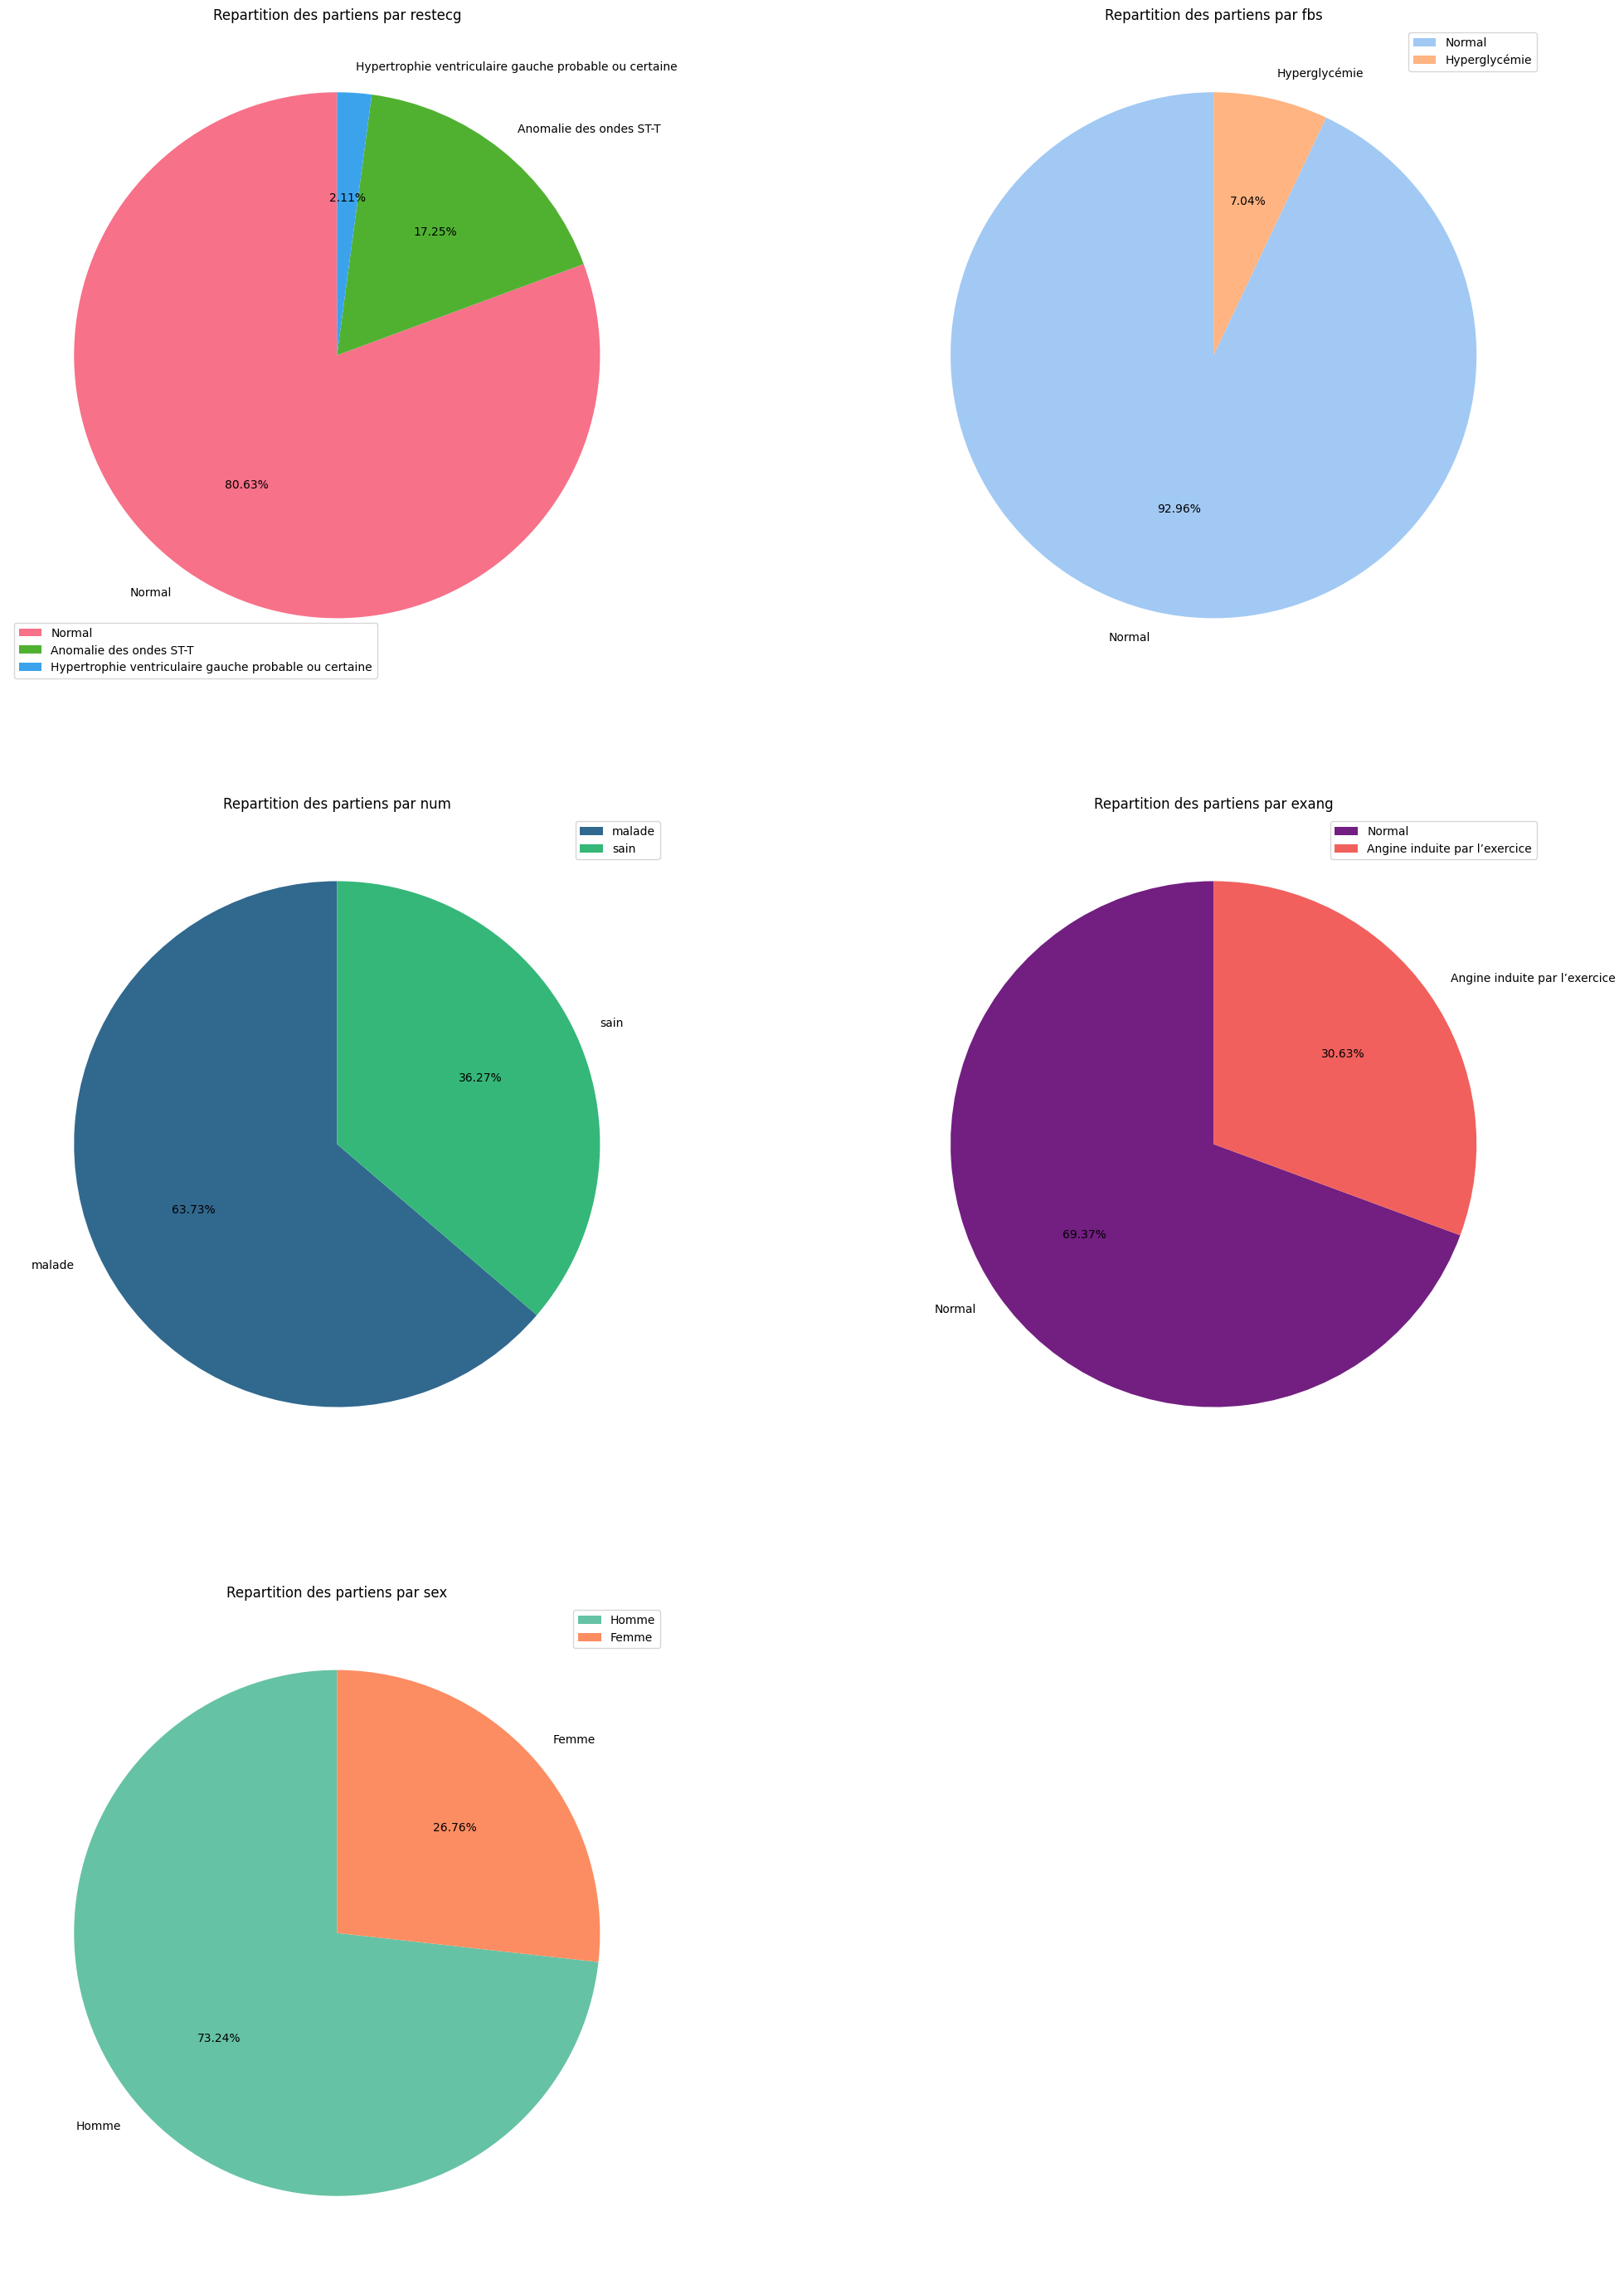

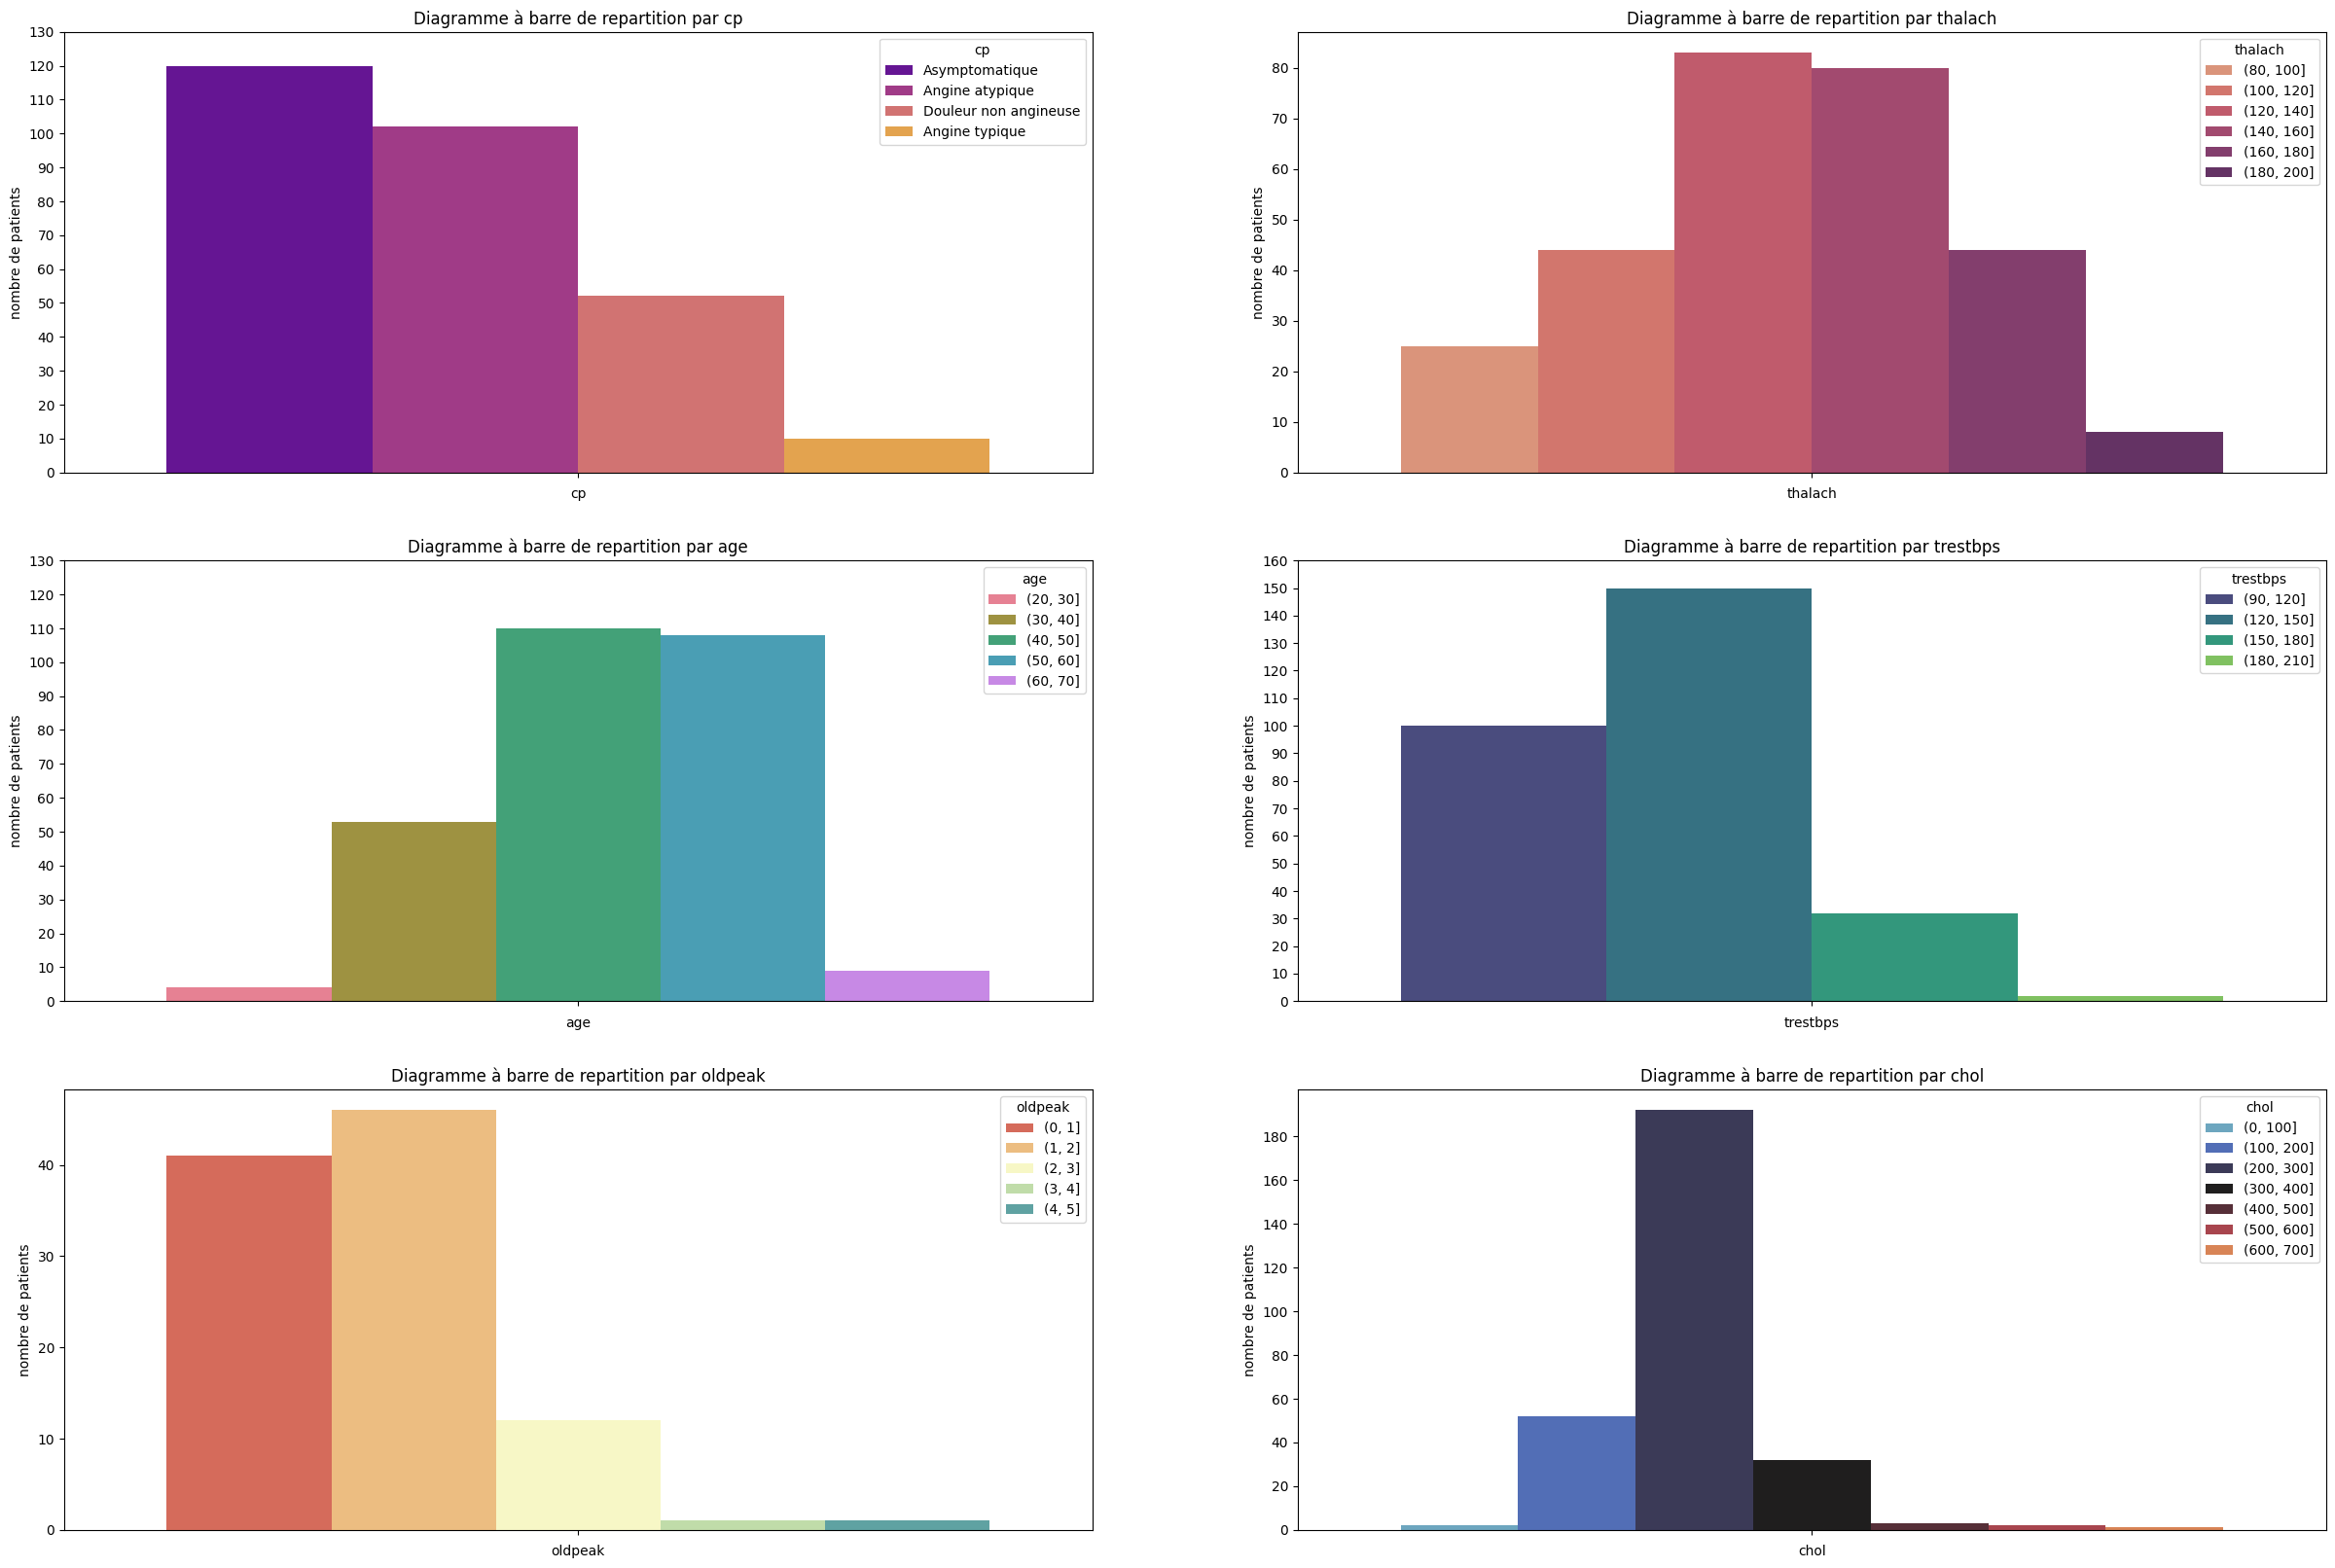

In [310]:
pie_charts = show_pie_charts(params=pie_charts_params)
bar_charts = show_bar_charts(params=bar_charts_params)
plt.show()

**interpretation**  : 

La majorité des patients est de sexe masculin et se trouve entre 40 et 60 ans.
Plus de la moitié des patients est malade  , avec une minorité (7.04%) qui présentent une hyperglycémie et une partie (17.25%) semble présenter des anomalies des ondes ST-T.
On remarque plusieurs cas majoritaire de douleur thoraxique **asymptomatique** et minoritaires pour **Anginge typique**.
La majorité des patients ont un taux de cholesterole entre [200,300] et certains ont un taux très éleves de cholesteroles entre 400 et 600.
**30.63%** des patients ont des douleurs après exercise.
On a une minorité de patients qui a une frequence cardiaque maximale entre 80 et 100.

On a un certain nombre de patients avec une pression artérielle au repos entre 150 et 210 qui pourrait être à risque.

On a une minorité de patient qui semble présenter un stress cardiaque et une partie bien que minoritaire semble présenter un taux de cholesterole superieur à 400